In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Recarregar dataset
df_ml = pd.read_parquet('../data/processed/dataset_features_v2.parquet')
df_ml['data'] = pd.to_datetime(df_ml['data'])
df_ml = df_ml.sort_values('data').reset_index(drop=True)

# Adicionar Google Trends
trends = pd.read_csv('../data/raw/google_trends_dengue_mt.csv',
                     skiprows=3, names=['mes', 'trends_dengue'])
trends['mes'] = pd.to_datetime(trends['mes'], format='%Y-%m')
trends['trends_dengue'] = pd.to_numeric(trends['trends_dengue'], errors='coerce')
trends['mes_periodo'] = trends['mes']

df_ml['mes_periodo'] = df_ml['data'].dt.to_period('M').dt.to_timestamp()
df_ml = df_ml.merge(trends[['mes_periodo','trends_dengue']], on='mes_periodo', how='left')
df_ml = df_ml.drop(columns=['mes_periodo'])
df_ml = df_ml.ffill().bfill()

print(f"✅ Dataset recarregado: {df_ml.shape}")

✅ Dataset recarregado: (2242, 56)


In [3]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS
from neuralforecast.losses.pytorch import MAE as NMAE
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("✅ neuralforecast importado!")

# Preparar dados no formato neuralforecast
# Requer colunas: unique_id, ds (data), y (target)
df_nf = df_ml[['data', 'casos']].copy()
df_nf.columns = ['ds', 'y']
df_nf['unique_id'] = 'MT'
df_nf['ds'] = pd.to_datetime(df_nf['ds'])
df_nf['y'] = df_nf['y'].astype(float)

# Divisão temporal — últimos 20% para teste
h = 28  # horizonte 28 dias
n_test = int(len(df_nf) * 0.20)

print(f"✅ Dataset preparado: {df_nf.shape}")
print(f"   Horizonte: {h} dias")
print(f"   Teste: {n_test} dias")
print(f"   Período teste: {df_nf['ds'].iloc[-n_test].date()} → {df_nf['ds'].iloc[-1].date()}")
print(df_nf.head(3))

✅ neuralforecast importado!
✅ Dataset preparado: (2242, 3)
   Horizonte: 28 dias
   Teste: 448 dias
   Período teste: 2023-10-08 → 2024-12-28
          ds     y unique_id
0 2018-02-12  24.0        MT
1 2018-02-13  27.0        MT
2 2018-02-14  38.0        MT


In [4]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS
from neuralforecast.losses.pytorch import MAE as NMAE

# Dividir treino/teste
df_train = df_nf.iloc[:-n_test]
df_test = df_nf.iloc[-n_test:]

print(f"Treino: {len(df_train)} | Teste: {len(df_test)}")

# ============================================================
# N-HiTS
# ============================================================
print("\n🔄 Treinando N-HiTS...")

nhits = NeuralForecast(
    models=[
        NHITS(
            h=h,
            input_size=90,
            max_steps=300,
            loss=NMAE(),
            stack_types=['identity','trend','seasonality'],
            n_freq_downsample=[12, 4, 1],
            scaler_type='standard',
            random_seed=42,
            enable_progress_bar=False,
        )
    ],
    freq='D'
)

nhits.fit(df_train)

# Predições
pred_nhits = nhits.predict()
pred_nhits = pred_nhits.reset_index(drop=True)

# Alinhar com valores reais
y_real_nh = df_test['y'].values[:len(pred_nhits)]
y_pred_nh = np.clip(pred_nhits['NHITS'].values, 0, None)

mae_nh = mean_absolute_error(y_real_nh, y_pred_nh)
r2_nh = r2_score(y_real_nh, y_pred_nh)

print(f"✅ N-HiTS: MAE={mae_nh:.2f} | R²={r2_nh:.3f}")

# ============================================================
# N-BEATS
# ============================================================
print("\n🔄 Treinando N-BEATS...")

nbeats = NeuralForecast(
    models=[
        NBEATS(
            h=h,
            input_size=90,
            max_steps=300,
            loss=NMAE(),
            stack_types=['trend','seasonality'],
            scaler_type='standard',
            random_seed=42,
            enable_progress_bar=False,
        )
    ],
    freq='D'
)

nbeats.fit(df_train)
pred_nbeats = nbeats.predict().reset_index(drop=True)
y_pred_nb = np.clip(pred_nbeats['NBEATS'].values, 0, None)

mae_nb = mean_absolute_error(y_real_nh, y_pred_nb)
r2_nb = r2_score(y_real_nh, y_pred_nb)

print(f"✅ N-BEATS: MAE={mae_nb:.2f} | R²={r2_nb:.3f}")

print(f"\n🏆 COMPARAÇÃO:")
print(f"{'Modelo':<30} {'R²':>8} {'MAE':>8}")
print(f"{'-'*48}")
print(f"{'Rolling Window LightGBM':<30} {'0.892':>8} {'17.69':>8}")
print(f"{'LightGBM otimizado':<30} {'0.871':>8} {'21.83':>8}")
print(f"{'CNN + BiLSTM':<30} {'0.756':>8} {'33.34':>8}")
print(f"{'N-HiTS':<30} {r2_nh:>8.3f} {mae_nh:>8.2f}")
print(f"{'N-BEATS':<30} {r2_nb:>8.3f} {mae_nb:>8.2f}")

Seed set to 42


Treino: 1794 | Teste: 448

🔄 Treinando N-HiTS...


AssertionError: Block type trend not found!

In [5]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, NBEATS
from neuralforecast.losses.pytorch import MAE as NMAE

print("\n🔄 Treinando N-HiTS...")
nhits = NeuralForecast(
    models=[
        NHITS(
            h=h,
            input_size=90,
            max_steps=300,
            loss=NMAE(),
            scaler_type='standard',
            random_seed=42,
            enable_progress_bar=False,
        )
    ],
    freq='D'
)
nhits.fit(df_train)
pred_nhits = nhits.predict().reset_index(drop=True)
y_real_nh = df_test['y'].values[:len(pred_nhits)]
y_pred_nh = np.clip(pred_nhits['NHITS'].values, 0, None)
mae_nh = mean_absolute_error(y_real_nh, y_pred_nh)
r2_nh = r2_score(y_real_nh, y_pred_nh)
print(f"✅ N-HiTS: MAE={mae_nh:.2f} | R²={r2_nh:.3f}")

print("\n🔄 Treinando N-BEATS...")
nbeats = NeuralForecast(
    models=[
        NBEATS(
            h=h,
            input_size=90,
            max_steps=300,
            loss=NMAE(),
            scaler_type='standard',
            random_seed=42,
            enable_progress_bar=False,
        )
    ],
    freq='D'
)
nbeats.fit(df_train)
pred_nbeats = nbeats.predict().reset_index(drop=True)
y_pred_nb = np.clip(pred_nbeats['NBEATS'].values, 0, None)
mae_nb = mean_absolute_error(y_real_nh, y_pred_nb)
r2_nb = r2_score(y_real_nh, y_pred_nb)
print(f"✅ N-BEATS: MAE={mae_nb:.2f} | R²={r2_nb:.3f}")

print(f"\n🏆 COMPARAÇÃO:")
print(f"{'Modelo':<30} {'R²':>8} {'MAE':>8}")
print(f"{'-'*48}")
print(f"{'Rolling Window LightGBM':<30} {'0.892':>8} {'17.69':>8}")
print(f"{'LightGBM otimizado':<30} {'0.871':>8} {'21.83':>8}")
print(f"{'CNN + BiLSTM':<30} {'0.756':>8} {'33.34':>8}")
print(f"{'N-HiTS':<30} {r2_nh:>8.3f} {mae_nh:>8.2f}")
print(f"{'N-BEATS':<30} {r2_nb:>8.3f} {mae_nb:>8.2f}")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



🔄 Treinando N-HiTS...


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogge

...

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 6.7 K                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ N-BEATS: MAE=6.59 | R²=0.374

🏆 COMPARAÇÃO:
Modelo                               R²      MAE
------------------------------------------------
Rolling Window LightGBM           0.892    17.69
LightGBM otimizado                0.871    21.83
CNN + BiLSTM                      0.756    33.34
N-HiTS                            0.521     5.50
N-BEATS                           0.374     6.59


C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Escala das predições N-HiTS:
  y_real: min=2.0, max=37.0, mean=18.6
  y_pred: min=6.8, max=25.2, mean=17.4

Shape: y_real=(28,), y_pred=(28,)


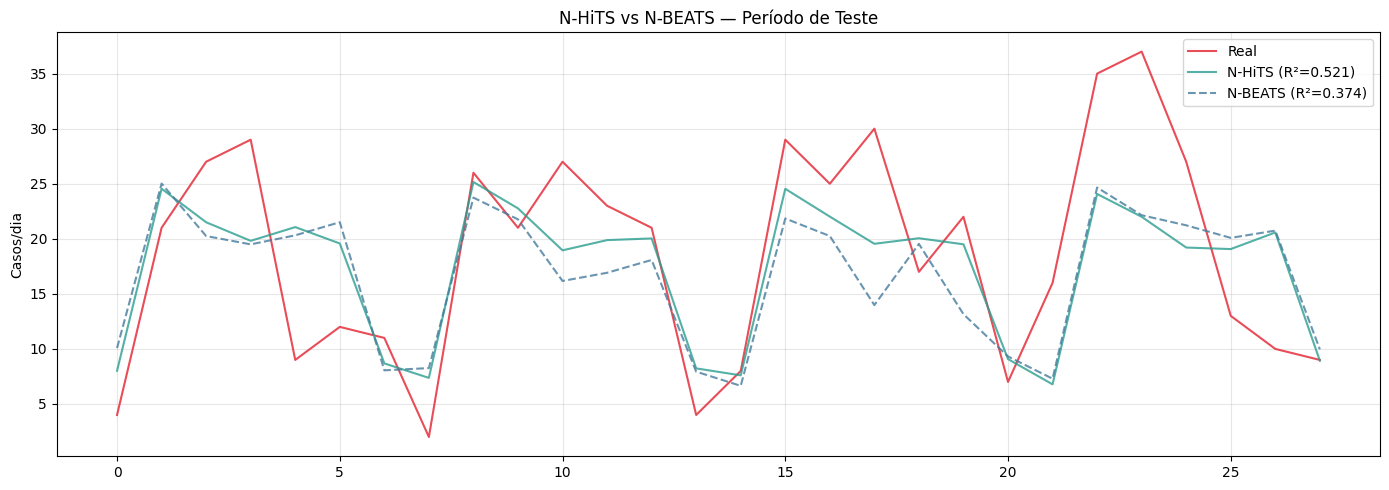

In [6]:
# Verificar escala das predições
print("Escala das predições N-HiTS:")
print(f"  y_real: min={y_real_nh.min():.1f}, max={y_real_nh.max():.1f}, mean={y_real_nh.mean():.1f}")
print(f"  y_pred: min={y_pred_nh.min():.1f}, max={y_pred_nh.max():.1f}, mean={y_pred_nh.mean():.1f}")
print(f"\nShape: y_real={y_real_nh.shape}, y_pred={y_pred_nh.shape}")

# Visualizar
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(y_real_nh)), y_real_nh, color='#e63946', 
        linewidth=1.5, label='Real', alpha=0.9)
ax.plot(range(len(y_pred_nh)), y_pred_nh, color='#2a9d8f', 
        linewidth=1.5, label=f'N-HiTS (R²={r2_nh:.3f})', alpha=0.8)
ax.plot(range(len(y_pred_nb)), y_pred_nb, color='#457b9d', 
        linewidth=1.5, label=f'N-BEATS (R²={r2_nb:.3f})', 
        alpha=0.8, linestyle='--')
ax.set_title('N-HiTS vs N-BEATS — Período de Teste')
ax.set_ylabel('Casos/dia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Previsão recursiva — avançar janela a cada 28 dias
print("🔄 Fazendo previsões recursivas N-HiTS...")

all_preds_nh = []
all_real_nh = []

# Avançar de 28 em 28 dias
for i in range(0, n_test - h + 1, h):
    # Dataset até o ponto atual
    df_temp = df_nf.iloc[:len(df_train) + i].copy()
    
    # Retreinar e predizer
    nhits_r = NeuralForecast(
        models=[NHITS(h=h, input_size=90, max_steps=200,
                      loss=NMAE(), scaler_type='standard',
                      random_seed=42, enable_progress_bar=False)],
        freq='D'
    )
    nhits_r.fit(df_temp)
    pred = nhits_r.predict().reset_index(drop=True)
    
    y_p = np.clip(pred['NHITS'].values, 0, None)
    y_r = df_nf['y'].iloc[len(df_train)+i : len(df_train)+i+h].values
    
    all_preds_nh.extend(y_p[:len(y_r)])
    all_real_nh.extend(y_r)
    print(f"  Janela {i//h + 1}: MAE={mean_absolute_error(y_r, y_p[:len(y_r)]):.1f}")

all_preds_nh = np.array(all_preds_nh)
all_real_nh = np.array(all_real_nh)

mae_nh_r = mean_absolute_error(all_real_nh, all_preds_nh)
r2_nh_r = r2_score(all_real_nh, all_preds_nh)

print(f"\n✅ N-HiTS recursivo:")
print(f"  MAE={mae_nh_r:.2f} | R²={r2_nh_r:.3f} | Dias avaliados={len(all_real_nh)}")

Seed set to 42


🔄 Fazendo previsões recursivas N-HiTS...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  Janela 16: MAE=19.8

✅ N-HiTS recursivo:
  MAE=27.36 | R²=0.805 | Dias avaliados=448


C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [8]:
# Previsão recursiva N-BEATS
print("🔄 Fazendo previsões recursivas N-BEATS...")

all_preds_nb = []

for i in range(0, n_test - h + 1, h):
    df_temp = df_nf.iloc[:len(df_train) + i].copy()
    
    nbeats_r = NeuralForecast(
        models=[NBEATS(h=h, input_size=90, max_steps=200,
                       loss=NMAE(), scaler_type='standard',
                       random_seed=42, enable_progress_bar=False)],
        freq='D'
    )
    nbeats_r.fit(df_temp)
    pred = nbeats_r.predict().reset_index(drop=True)
    y_p = np.clip(pred['NBEATS'].values, 0, None)
    y_r = df_nf['y'].iloc[len(df_train)+i : len(df_train)+i+h].values
    all_preds_nb.extend(y_p[:len(y_r)])

all_preds_nb = np.array(all_preds_nb)
mae_nb_r = mean_absolute_error(all_real_nh, all_preds_nb)
r2_nb_r = r2_score(all_real_nh, all_preds_nb)
print(f"✅ N-BEATS recursivo: MAE={mae_nb_r:.2f} | R²={r2_nb_r:.3f}")

# Comparação final atualizada
print(f"\n🏆 RANKING ATUALIZADO:")
print(f"{'Modelo':<35} {'R²':>8} {'MAE':>8}")
print(f"{'-'*53}")
modelos = [
    ('Rolling Window LightGBM', 0.892, 17.69),
    ('LightGBM otimizado', 0.871, 21.83),
    ('N-HiTS recursivo', r2_nh_r, mae_nh_r),
    ('CNN + BiLSTM', 0.756, 33.34),
    ('N-BEATS recursivo', r2_nb_r, mae_nb_r),
    ('LSTM v2', 0.664, 38.75),
    ('TFT série única', 0.459, 43.97),
    ('TFT multi-município', 0.230, 9.27),
]
for nome, r2, mae in sorted(modelos, key=lambda x: x[1], reverse=True):
    flag = '🏆' if r2 == max(m[1] for m in modelos) else '  '
    print(f"{flag} {nome:<33} {r2:>8.3f} {mae:>8.2f}")

Seed set to 42


🔄 Fazendo previsões recursivas N-BEATS...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 6.7 K                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 6.7 K                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ N-BEATS recursivo: MAE=30.10 | R²=0.787

🏆 RANKING ATUALIZADO:
Modelo                                    R²      MAE
-----------------------------------------------------
🏆 Rolling Window LightGBM              0.892    17.69
   LightGBM otimizado                   0.871    21.83
   N-HiTS recursivo                     0.805    27.36
   N-BEATS recursivo                    0.787    30.10
   CNN + BiLSTM                         0.756    33.34
   LSTM v2                              0.664    38.75
   TFT série única                      0.459    43.97
   TFT multi-município                  0.230     9.27


C:\Users\edy85\miniconda3\envs\dengue-mt\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [9]:
# Salvar ranking final
ranking = pd.DataFrame([
    ('Rolling Window LightGBM', 0.892, 17.69, 'diário', 'produção'),
    ('LightGBM otimizado', 0.871, 21.83, 'diário', 'baseline'),
    ('N-HiTS recursivo', r2_nh_r, mae_nh_r, 'diário', 'deep learning'),
    ('N-BEATS recursivo', r2_nb_r, mae_nb_r, 'diário', 'deep learning'),
    ('CNN + BiLSTM', 0.756, 33.34, 'diário', 'deep learning'),
    ('LSTM v2', 0.664, 38.75, 'diário', 'deep learning'),
    ('TFT série única', 0.459, 43.97, 'diário', 'deep learning'),
    ('TFT multi-município', 0.230, 9.27, 'semanal', 'deep learning'),
], columns=['modelo','r2','mae','granularidade','categoria'])

ranking.to_csv('../reports/ranking_final_modelos.csv', index=False)
print("✅ Ranking salvo!")
print(ranking.to_string(index=False))

✅ Ranking salvo!
                 modelo       r2       mae granularidade     categoria
Rolling Window LightGBM 0.892000 17.690000        diário      produção
     LightGBM otimizado 0.871000 21.830000        diário      baseline
       N-HiTS recursivo 0.805378 27.364318        diário deep learning
      N-BEATS recursivo 0.787128 30.098701        diário deep learning
           CNN + BiLSTM 0.756000 33.340000        diário deep learning
                LSTM v2 0.664000 38.750000        diário deep learning
        TFT série única 0.459000 43.970000        diário deep learning
    TFT multi-município 0.230000  9.270000       semanal deep learning
